# <center>Segmentación de Clientes del Centro Comercial</center>

### Objetivo :
- Clasificar / agrupar clientes del centro comercial según características numéricas y categóricas.
- Es un problema de **Aprendizaje No Supervisado**.

### <center>Atributos del Conjunto de Datos</center>
    
- **CustomerID** : Identificador único asignado al cliente
- **Gender** : Género del cliente
- **Edad** : Edad del cliente
- **Annual Income (k\\$)** : Ingreso anual del cliente
- **Spending Score (1-1000)** : Puntaje asignado por el centro comercial según el comportamiento y el patrón de gasto del cliente

### Contenido del Notebook :
- Información del conjunto de datos
- Análisis Exploratorio de Datos (EDA)
- Resumen del EDA
- Ingeniería de Características
- Modelado
- Conclusión

### Qué aprenderás :
- Técnicas de visualización de datos.
- Información sobre el algoritmo de agrupamiento K-Means.
- Pruebas estadísticas para la selección de hiperparámetros.
- Diferencia en el rendimiento del modelo cuando se entrena con el conjunto de datos original y normalizado.

### Trabajo reciente :

- [Clasificación Binaria](https://www.kaggle.com/competitions/titanic/discussion/352223) **: Describe el enfoque requerido para resolver problemas de Clasificación Binaria explicado mediante notebooks con código claro y fácil de entender.**
- [Análisis de Series Temporales](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/discussion/352205) **: Describe los conceptos básicos del Análisis de Series Temporales explicado mediante notebooks con código claro y fácil de entender.**

### ¡Comencemos!

# <center>Información del Conjunto de Datos</center>

### Importar las librerías necesarias :

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [4]:
data = pd.read_csv('./Mall_Customers.csv')
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Información de los datos :

In [5]:
data.shape

(200, 5)

In [6]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


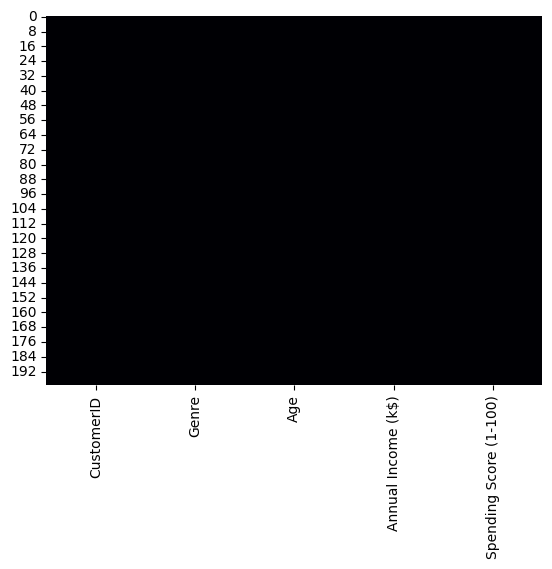

In [8]:
sns.heatmap(data.isnull(),cmap = 'magma',cbar = False);

- ¡No hay valores nulos presentes en los datos!

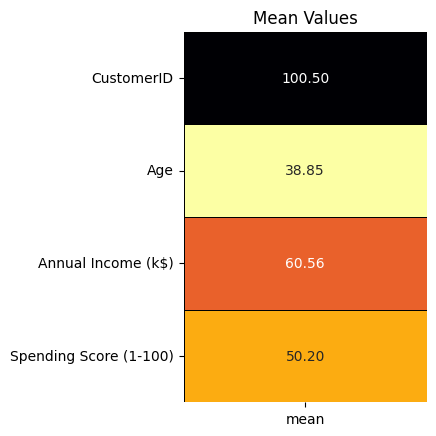

In [9]:
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))

plt.subplot(1,1,1)
sns.heatmap(data.describe().T[['mean']],cmap = 'inferno_r',annot = True,fmt = '.2f',linecolor = 'black',linewidths = 0.4,cbar = False);
plt.title('Mean Values');

fig.tight_layout(pad = 3)

- La edad promedio de los clientes en el conjunto de datos se encuentra en los últimos 30 años, es decir, **38.85**.
- El ingreso anual promedio de los clientes es **60.56**, ligeramente por debajo de la mediana de ingresos de EE. UU. en 2018 (63k$).
- El puntaje promedio de gasto (**Spending Score (1-100)**) de los clientes del centro comercial está en el centro con **50.20**.

# <center>Análisis Exploratorio de Datos</center>

### División de características en Numéricas y Categóricas :

In [10]:
col = list(data.columns)
categorical_features = []
numerical_features = []
for i in col:
    if len(data[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

Categorical Features : Genre
Numerical Features : CustomerID Age Annual Income (k$) Spending Score (1-100)


- Aquí, las características categóricas se definen si el atributo tiene menos de 6 elementos únicos; de lo contrario, es una característica numérica.
- El enfoque típico para esta división de características también puede basarse en los tipos de datos de los elementos del atributo respectivo.

**Ejemplo :** tipo de dato = entero, atributo = característica numérica; tipo de dato = cadena, atributo = característica categórica

- Para este conjunto de datos, como el número de características es pequeño, también podemos revisar el conjunto de datos manualmente.

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = data.copy(deep = True)

df1['Gender'] = le.fit_transform(df1['Genre'])
df1.drop(columns='Genre', inplace=True)

print('Label Encoder Transformation')
print(df1['Gender'].unique(),' = ',le.inverse_transform(df1['Gender'].unique()))

Label Encoder Transformation
[1 0]  =  ['Male' 'Female']


- Creando una copia profunda del conjunto de datos original y codificando con etiquetas los datos de texto de **Gender**.
- Las modificaciones en el conjunto de datos original no se reflejarán en esta copia profunda.
- Por eso usamos esta copia profunda del conjunto de datos que tiene **Gender** convertido en valores numéricos para fines de visualización y modelado.

### Distribución de características categóricas y numéricas :

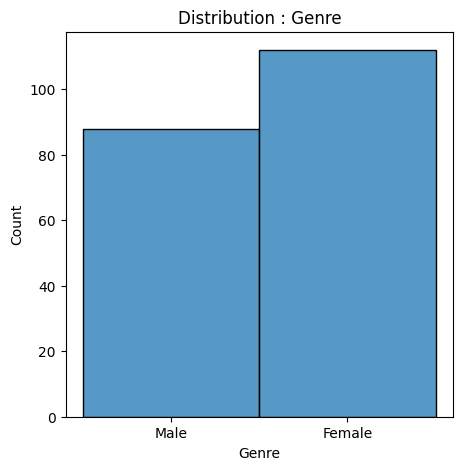

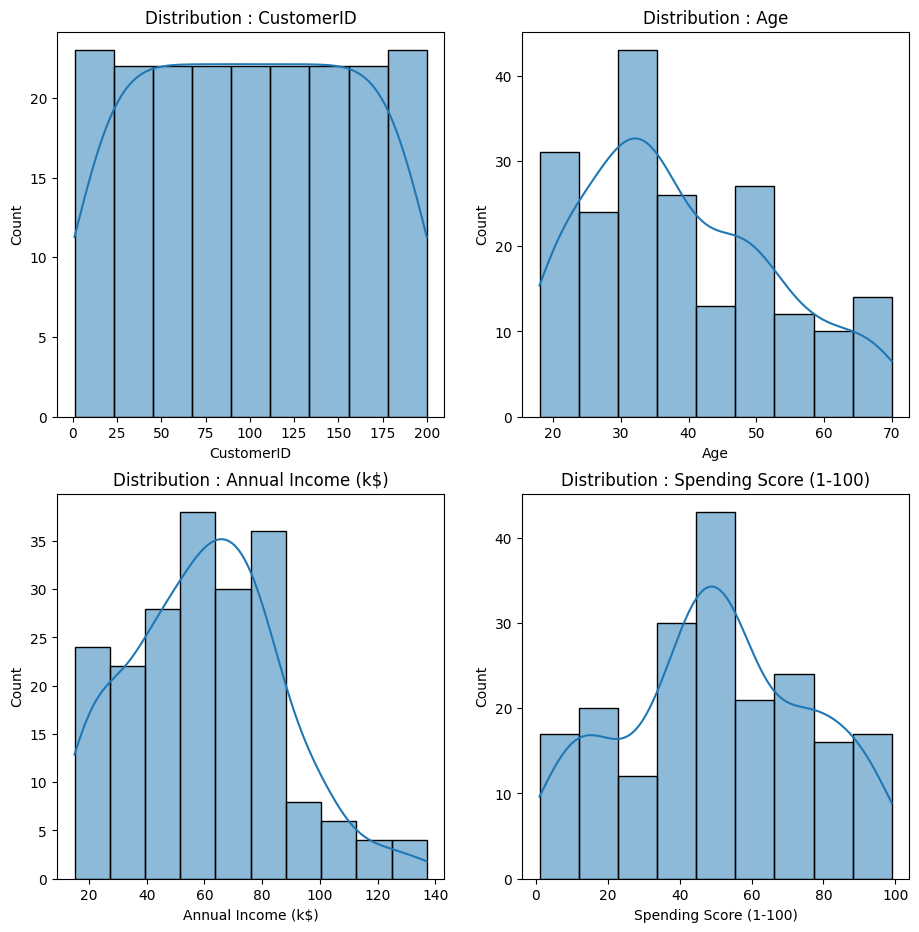

In [15]:
fig, ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))
for i in range(len(categorical_features)):
    plt.subplot(1,1,i+1)
    sns.histplot(df1[categorical_features[i]], kde=False)
    title = 'Distribution : ' + categorical_features[i]
    plt.title(title)
    
fig, ax = plt.subplots(nrows = 2,ncols = 2,figsize = (11,11))
for i in range(len(numerical_features)):
    plt.subplot(2,2,i+1)
    sns.histplot(data[numerical_features[i]], kde=True)
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

- **Gender**, la única característica categórica, muestra una distribución **normal**.
- La distribución de **Edad** y **Annual Income (k\\$)** está sesgada positivamente (hacia la derecha).
- La distribución de datos de **Spending Score (1-100)** es similar al patrón de **Head and Shoulders** observado en gráficos de valores.
- Muestra el precio de una acción subiendo hasta un pico y luego descendiendo a la base del movimiento previo. Algo similar se observa con los **2 hombros** formados alrededor de los valores **20 y 80**, con la **cabeza** centrada entre **40 - 60**.
- Eliminaremos la característica **CustomerID** porque es solo un número asignado a un cliente.

In [ ]:
numerical_features.remove('CustomerID')

### Características Categóricas :

C:\Users\valie\AppData\Local\Temp\ipykernel_66972\1090740258.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Gender', data=df1, palette=colors, edgecolor='black');
C:\Users\valie\AppData\Local\Temp\ipykernel_66972\1090740258.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female','Male'])


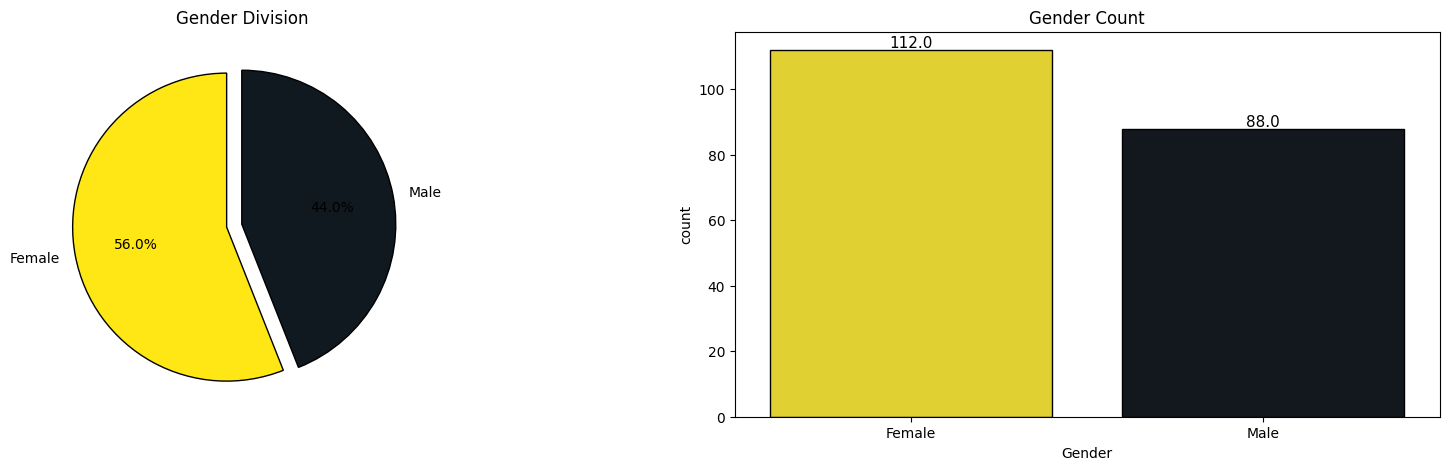

In [20]:
l = list(df1['Gender'].value_counts())
circle = [l[0] / len(l) * 100, l[1] / len(l) * 100]
colors = ['#FEE715','#101820']

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (20,5))

plt.subplot(1,2,1)
plt.pie(circle,labels = ['Female','Male'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Gender Division');

plt.subplot(1,2,2)
ax = sns.countplot(x='Gender', data=df1, palette=colors, edgecolor='black');
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.75, rect.get_height(), horizontalalignment='center', fontsize = 11)
plt.title('Gender Count')
ax.set_xticklabels(['Female','Male'])

plt.show()

- Para el conjunto de datos anterior, las clientes **femeninas** superan ligeramente a los clientes **masculinos**.

### Características Numéricas vs Características Categóricas :

C:\Users\valie\AppData\Local\Temp\ipykernel_66972\3450048633.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=feature, data=df1, palette=colors, ax=ax)
C:\Users\valie\AppData\Local\Temp\ipykernel_66972\3450048633.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Gender', y=feature, data=df1, palette=colors, ax=ax)
C:\Users\valie\AppData\Local\Temp\ipykernel_66972\3450048633.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=feature, data=df1, palette=colors, ax=ax)
C:\Users\valie\AppData\Local\Temp\

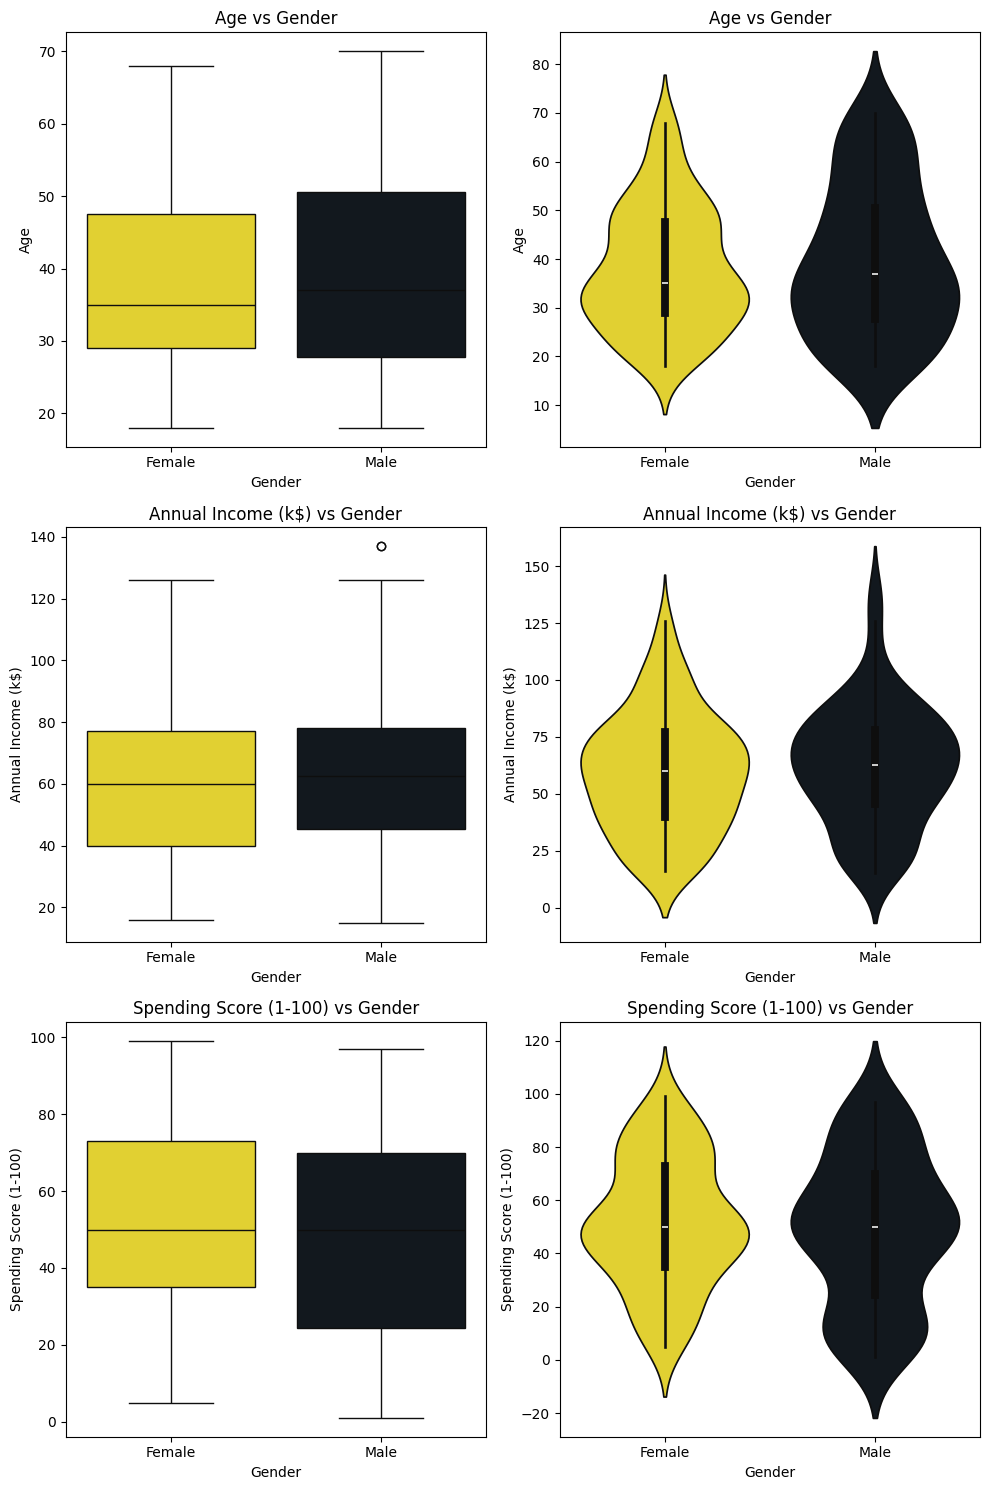

In [29]:
# Filtrar solo las columnas que realmente existen en df1
valid_features = [col for col in numerical_features if col in df1.columns]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))
axes = axes.flatten()

for i, feature in enumerate(valid_features):
    # Boxplot
    ax = axes[i*2]
    sns.boxplot(x='Gender', y=feature, data=df1, palette=colors, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Female', 'Male'])
    ax.set_title(f"{feature} vs Gender")

    # Violinplot
    ax = axes[i*2 + 1]
    sns.violinplot(x='Gender', y=feature, data=df1, palette=colors, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Female', 'Male'])
    ax.set_title(f"{feature} vs Gender")

plt.tight_layout()
plt.show()


- El rango de **Edad** de las clientas **femeninas** es de **30 hasta poco menos de 50**, mientras que el rango de **Edad** de los clientes **masculinos** es de **poco menos de 30 a 50**.
- Para ambos **géneros**, se observa una concentración en el rango de edad de **30 - 35**. La mediana de **Edad** de los **masculinos** es ligeramente mayor que la de las **femeninas**.
- Para **Annual Income (k\\$)**, el ingreso de las clientas **femeninas** comienza en **40k**, mientras que el de los clientes **masculinos** está por encima de este valor.
- La mediana de **Annual Income (k\\$)** para ambos **géneros** está cerca de **60k**. El **Annual Income (k\\$)** de los clientes **masculinos** se estrecha muy bruscamente en el punto máximo con algunos valores atípicos en comparación con las clientas **femeninas**.
- La mediana de **Spending Score (1-100)** de ambos **géneros** es la misma a pesar de tener puntos de inicio diferentes: **poco menos de 40** para las **femeninas** y **poco más de 20** para los **masculinos**.
- Ambos **géneros** muestran una fuerte acumulación en el valor mediano, especialmente las clientas **femeninas**. Sin embargo, los clientes **masculinos** también muestran una pequeña pero significativa acumulación en el rango de **0 - 20**.

### Características Numéricas vs Características Numéricas con respecto a la Característica Categórica :

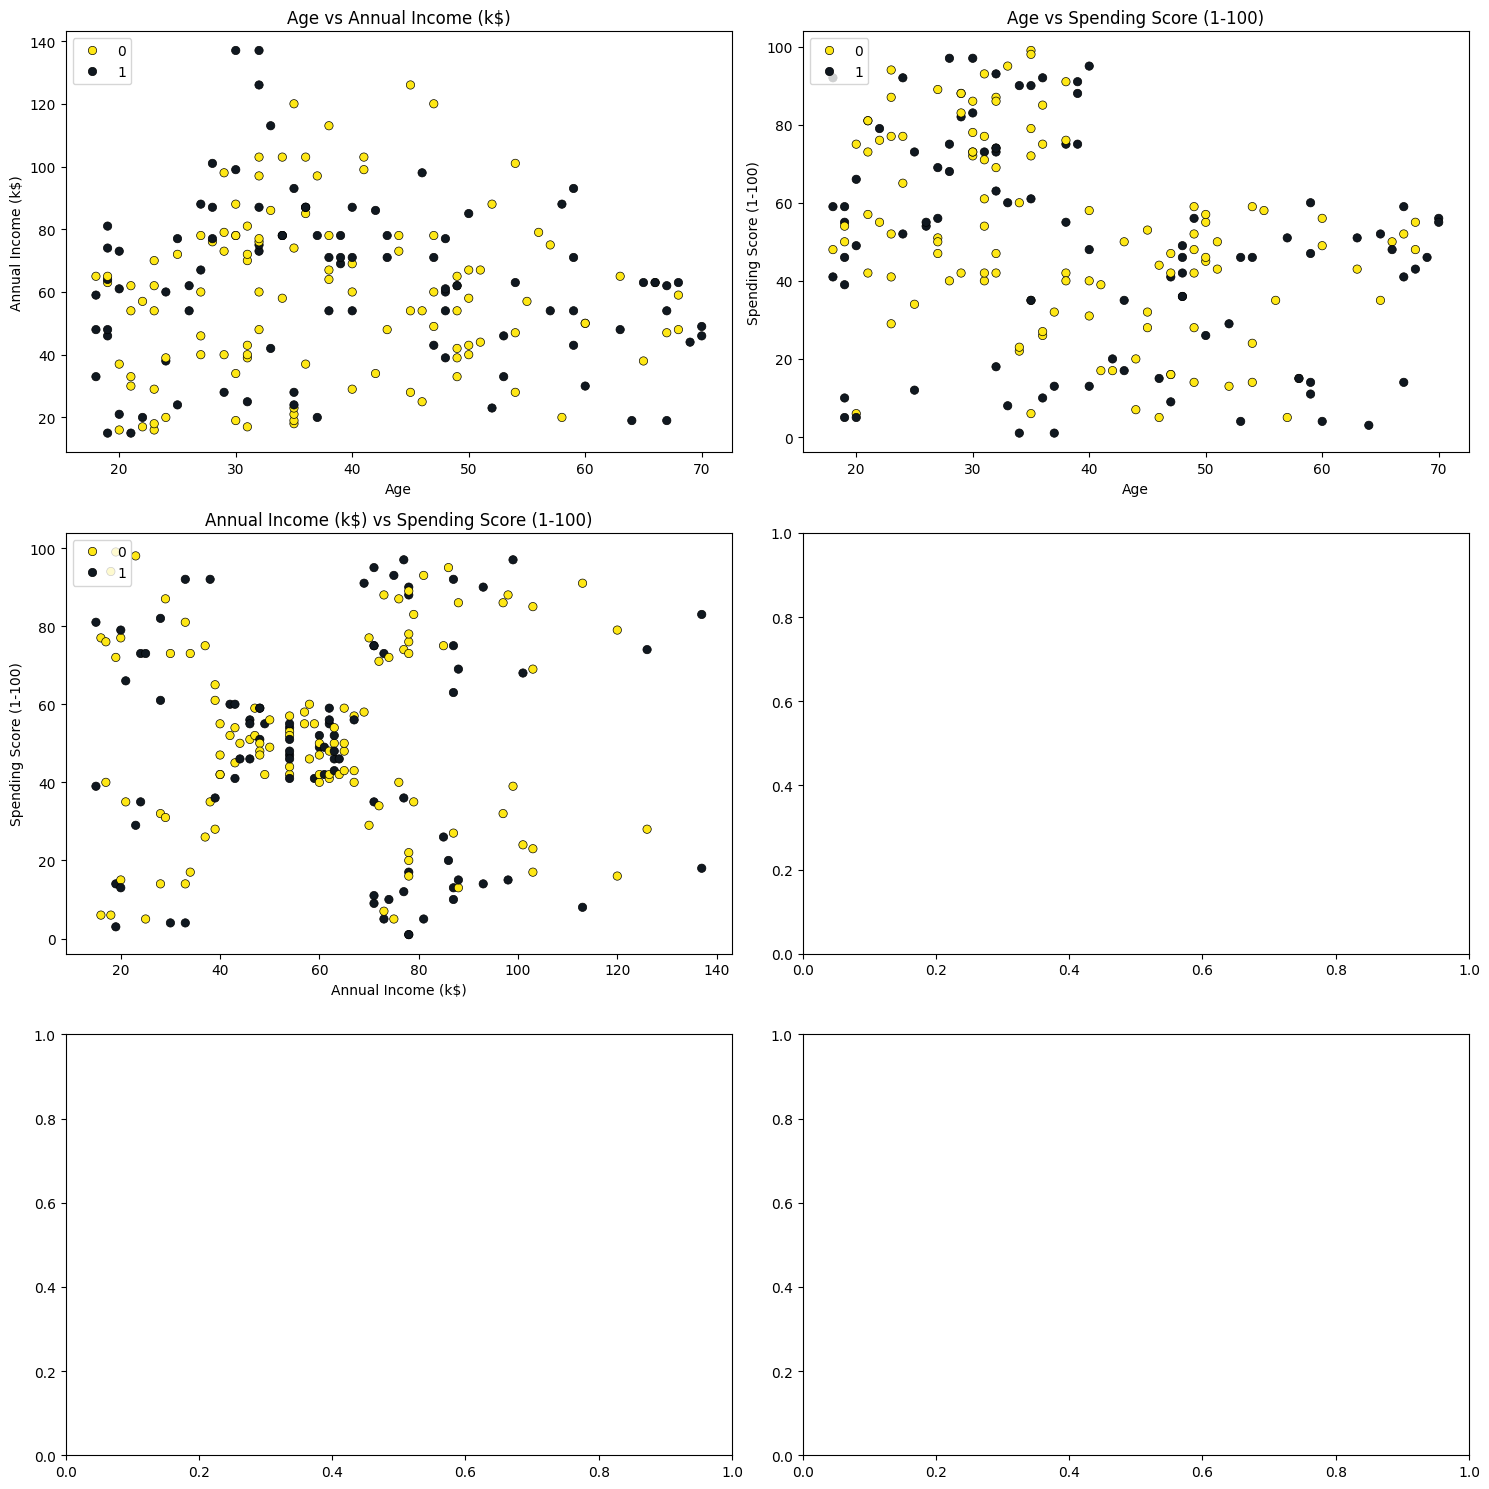

In [33]:
# Filtrar columnas que existen en df1
valid_features = [col for col in numerical_features if col in df1.columns]

# Generar pares únicos
pairs = [(valid_features[i], valid_features[j]) 
         for i in range(len(valid_features)-1) 
         for j in range(i+1, len(valid_features))]

# Tomar solo los primeros 6 pares
pairs = pairs[:6]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for a, (x_feat, y_feat) in enumerate(pairs):
    ax = axes[a]
    sns.scatterplot(
        x=x_feat, y=y_feat, data=df1,
        hue='Gender', palette=colors,
        edgecolor='black', ax=ax
    )
    ax.legend(loc='upper left')
    ax.set_title(f"{x_feat} vs {y_feat}")

plt.tight_layout()
plt.show()



- Los puntos de datos de **Annual Income (k\\$)** están presentes en todos los valores de **Edad**; **Gender** no aporta información significativa.
- Para **Spending Score (1-100)**, se puede observar claramente que los rangos de **Edad** **20 - 30** muestran hábitos de gasto muy altos.
- El grupo de **Edad** **30 - 40** destaca ambos extremos de los hábitos de gasto del cliente. El grupo de edad **40 - 70** muestra el otro extremo de hábitos de gasto con valores bajos.
- En la comparación **Annual Income (k\\$) vs Spending Score (1-100)** se pueden observar 5 grupos distintos. Para valores de **Annual Income (k\\$)** entre **0 y 40**, los datos muestran 2 grupos de clientes con **Spending Score (1-100)** entre **0 y 40** y entre **60 y 100**.
- Después de ese extremo, los datos destacan el grupo intermedio de clientes con **Annual Income (k\\$)** entre **40 y 70k** y **Spending Score (1-100)** entre **40 y 60**.
- Los valores de **Annual Income (k\\$)** entre **70 y 140k** definen el otro extremo, dividido en 2 grupos según los valores de **Spending Score (1-100)** (0-40 y 60-100).

# <center>Resumen del EDA</center>

- En los datos anteriores del centro comercial, las clientas **femeninas** son más que los clientes **masculinos**. Los datos de **Gender** están bastante equilibrados respecto a las demás características.
- Los clientes del centro comercial se pueden dividir por sus grupos de **Edad** :
    - **20 - 30** 
    - **30 - 40**
    - **40 - 70**. 
- La mediana de **Ingreso Anual (k\$)** de ambos **géneros** es aproximadamente **60k**. Muestra 3 grupos de valores : 
    - **0 - 40k** 
    - **40 - 70k**
    - **70 - 140k**.
- El **Spending Score (1-100)** de las clientas **femeninas** es mayor que el de los clientes **masculinos**. También puede dividir a los clientes en 3 grupos :
    - **0 - 40**
    - **40 - 60**
    - **60 - 100**
- Con la combinación de los valores anteriores, los **Clientes del Centro Comercial** pueden segmentarse, lo que permite atenderlos de forma más específica.

# <center>Ingeniería de Características</center>

### Matriz de Correlación :

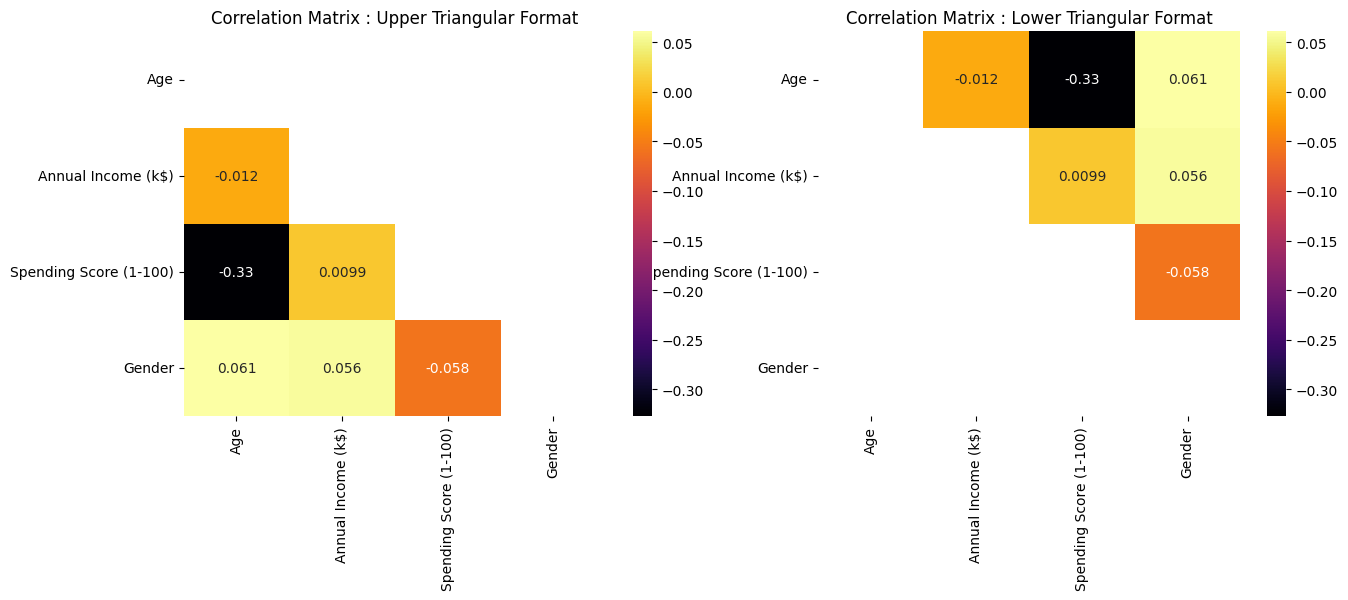

In [35]:
numeric_df1 = df1.select_dtypes(include=[np.number])
ut = np.triu(numeric_df1.corr())
lt = np.tril(numeric_df1.corr())

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

plt.subplot(1,2,1)
sns.heatmap(numeric_df1.corr(), cmap='inferno', annot=True, cbar=True, mask=ut)
plt.title('Correlation Matrix : Upper Triangular Format')

plt.subplot(1,2,2)
sns.heatmap(numeric_df1.corr(), cmap='inferno', annot=True, cbar=True, mask=lt)
plt.title('Correlation Matrix : Lower Triangular Format')

if 'CustomerID' in df1.columns:
    df1.drop(columns='CustomerID', inplace=True)


- Ambas matrices mostradas son iguales. Esto se hace únicamente con fines de visualización. Este truco puede utilizarse cuando el conjunto de datos tiene demasiadas características para revisar.
- **CustomerID** muestra una correlación positiva muy alta con **Annual Income (k\\$)** (los clientes están ordenados según su ingreso). No incluiremos **CustomerID** para el modelado.
- **Gender** no muestra ninguna relación con las demás características. Es bastante neutral, con todos los valores cerca de 0.
- **Spending Score (1-100)** y **Edad** muestran una correlación negativa; es decir, si el valor de una característica aumenta, el valor de otra disminuye, ¡y viceversa también es cierto!
- Esta información se obtiene de la sección **EDA**; los valores de la matriz de correlación respaldan aún más la evidencia.
- Ahora pasaremos a la sección de modelado creando combinaciones de estas características y encontrando diferentes formas en las que los clientes del centro comercial pueden segmentarse.

### Escalado de Datos :

- El modelo de aprendizaje automático no entiende las unidades de los valores de las características. Trata la entrada como un número simple, pero no entiende el verdadero significado de ese valor. Por eso, es necesario escalar los datos.

- Tenemos 2 opciones para escalar los datos :
    
    1) **Normalización** 
    
    2) **Standardization**. 


- Como la mayoría de los algoritmos asume que los datos tienen una distribución normal (gaussiana), se realiza **Normalización** en las características que no muestran una distribución normal y se lleva a cabo **Estandarización** para las características que sí se distribuyen normalmente pero cuyo rango de valores es muy grande o muy pequeño en comparación con otras.

- Para el conjunto de datos anterior, hemos realizado **Normalización** en 3 características: **Edad**, **Ingreso Anual (k\$)** y **Spending Score (1-100)**. La característica **Gender** se dejó sin cambios.

In [36]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

# Label Encoding 
df2 = df1.copy(deep = True)

# Normalization
df2['Age'] = mms.fit_transform(df2[['Age']])
df2['Annual Income (k$)'] = mms.fit_transform(df2[['Annual Income (k$)']])
df2['Spending Score (1-100)'] = mms.fit_transform(df2[['Spending Score (1-100)']])

- Para resaltar la diferencia en el rendimiento de los modelos cuando se entrenan con el conjunto de datos original y el conjunto normalizado, creamos una copia del conjunto original y aplicamos en ella la transformación de normalización.

**¡Ahora pasaremos a la sección de modelado!**

# <center>Modelado</center>

- **Aprendizaje No Supervisado**: es un problema donde la variable objetivo / característica es desconocida. Los problemas de **Aprendizaje No Supervisado** ocurren ampliamente en el ámbito médico, donde se toman múltiples lecturas y las enfermedades subyacentes son desconocidas.
- Por lo tanto, buscar patrones mediante técnicas de visualización nos ofrece información subyacente que no se puede comprender solo observando los datos tabulares.
- Sin embargo, cuando el tamaño de los conjuntos de datos es muy grande y hay demasiadas características, la visualización de datos puede ser una tarea tediosa. Por eso recurrimos al algoritmo de **K-Means Clustering**, que **no admite características categóricas**.
- Es el algoritmo más preferido para tratar el **Aprendizaje No Supervisado**, ya que encuentra clústeres/grupos en los datos mediante un enfoque matemático:
    - Selecciona 2 centroides aleatoriamente (supongamos k = 2).
    - Se calcula la distancia entre los centroides y todos los puntos de datos.
    - Si el punto de datos está más cerca de uno de los centroides, se etiqueta con ese centroide y viceversa.
    - Para los 2 clústeres formados, se calcula el valor promedio de los puntos agrupados y esos valores promedio definen los nuevos clústeres.
    - Este proceso se repite hasta que ambos centroides convergen en puntos fijos.
- El hiperparámetro **k** define el número de clústeres o grupos en los que se divide el dato. Para seleccionar valores de **k**, usamos 2 pruebas estadísticas:
    - **Método del codo**: es un método que grafica la suma de errores al cuadrado para un rango de valores de **k**. Si este gráfico parece un brazo, se selecciona el valor de **k** que se asemeja a un **codo**. A partir de ese valor de **codo**, la suma de valores al cuadrado (inercia) comienza a disminuir de forma lineal y se considera un valor óptimo.
    - **Método de la puntuación de silueta**: evalúa la calidad de los clústeres en términos de qué tan bien se agrupan los puntos de datos con otros puntos similares. Esta puntuación se calcula usando la fórmula de distancia y se selecciona el valor de **k** con la puntuación más alta para el modelado.

**Ahora crearemos modelos entrenándolos con las combinaciones de características seleccionadas a partir de las pruebas anteriores y también los visualizaremos.**

In [37]:
# Dropping categorical feature 
df1.drop(columns = 'Gender',inplace = True)
df2.drop(columns = 'Gender',inplace = True)

### <center>Edad - Ingreso Anual (k\$)</center>

In [38]:
m1 = df1[['Age','Annual Income (k$)']].values # Original Dataset
m2 = df2[['Age','Annual Income (k$)']].values # Normalized Dataset

### Conjunto de datos original :

#### Método del codo y método de la puntuación de silueta :

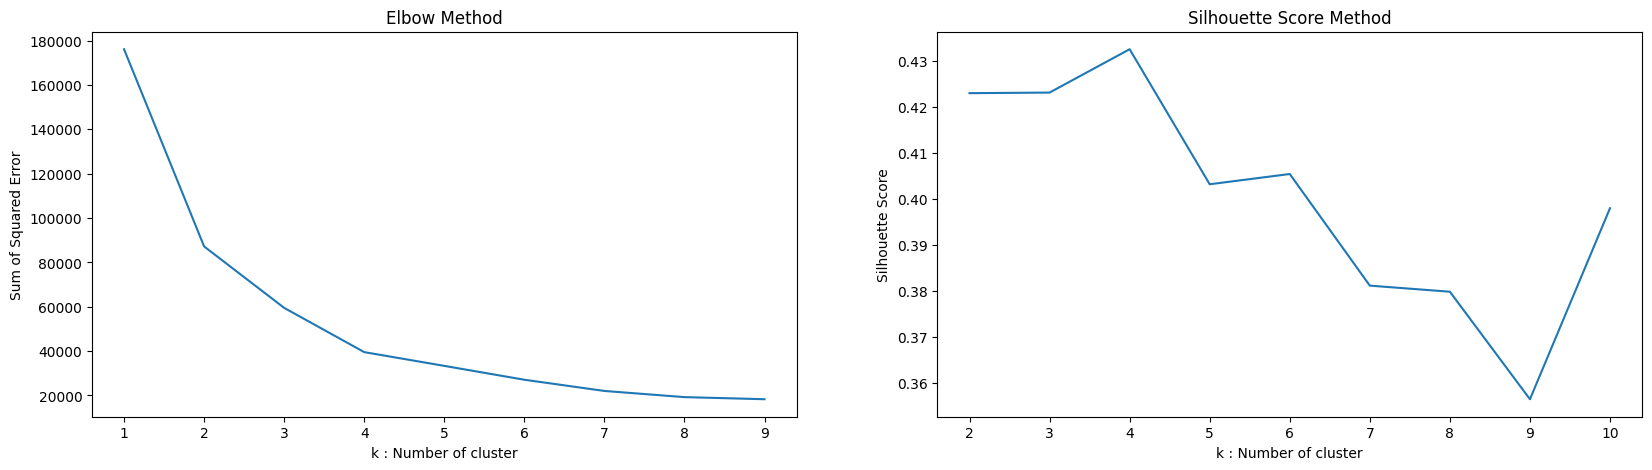

In [39]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 4**

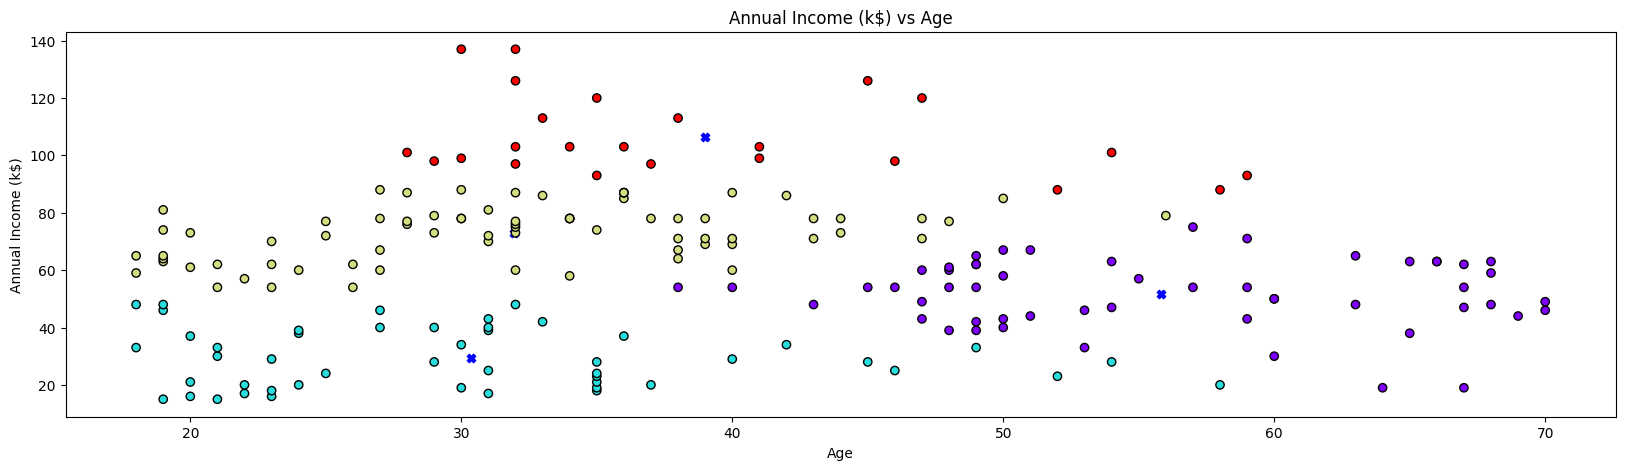

In [40]:
model = KMeans(n_clusters = 4,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df1['Age'], df1['Annual Income (k$)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

### Conjunto de datos normalizado :

#### Método del codo y método de la puntuación de silueta :

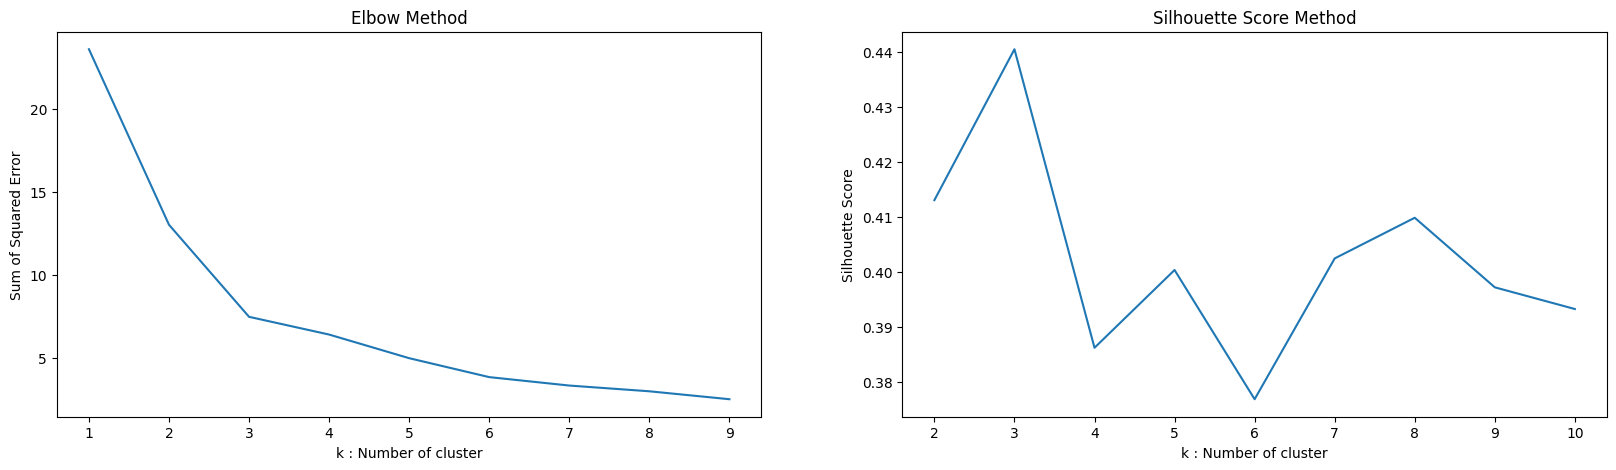

In [41]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 3**

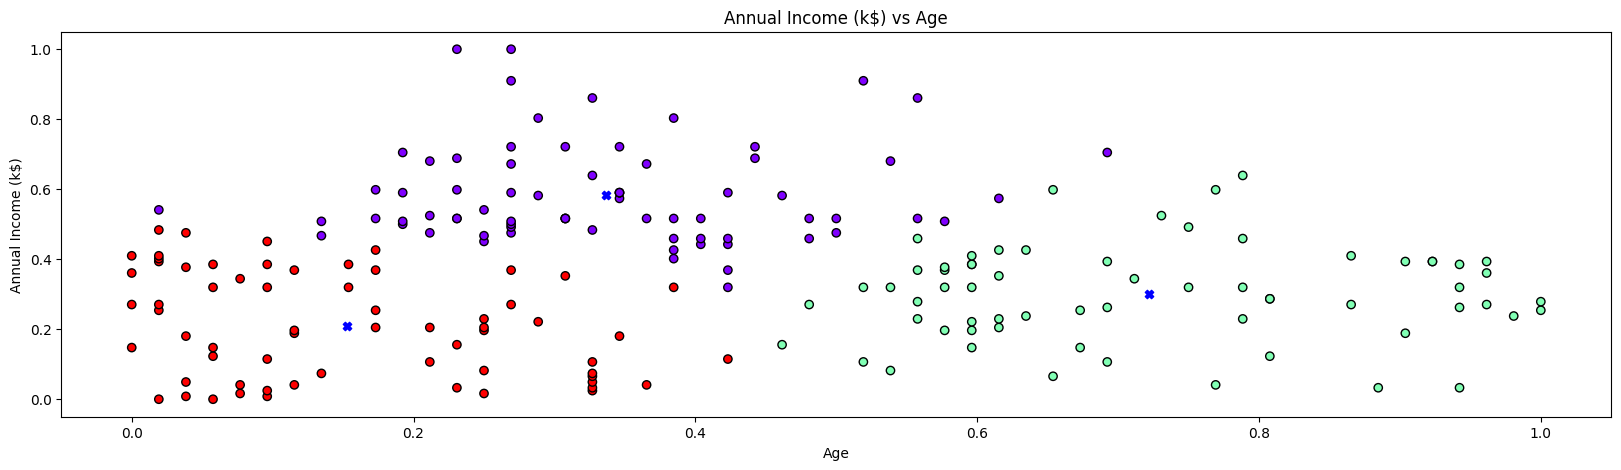

In [42]:
model = KMeans(n_clusters = 3,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df2['Age'], df2['Annual Income (k$)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

### <center>Edad - Puntaje de Gasto (1-100)</center>

In [43]:
m1 = df1[['Age','Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Age','Spending Score (1-100)']].values # Normalized Dataset

### Conjunto de datos original :

#### Método del codo y método de la puntuación de silueta :

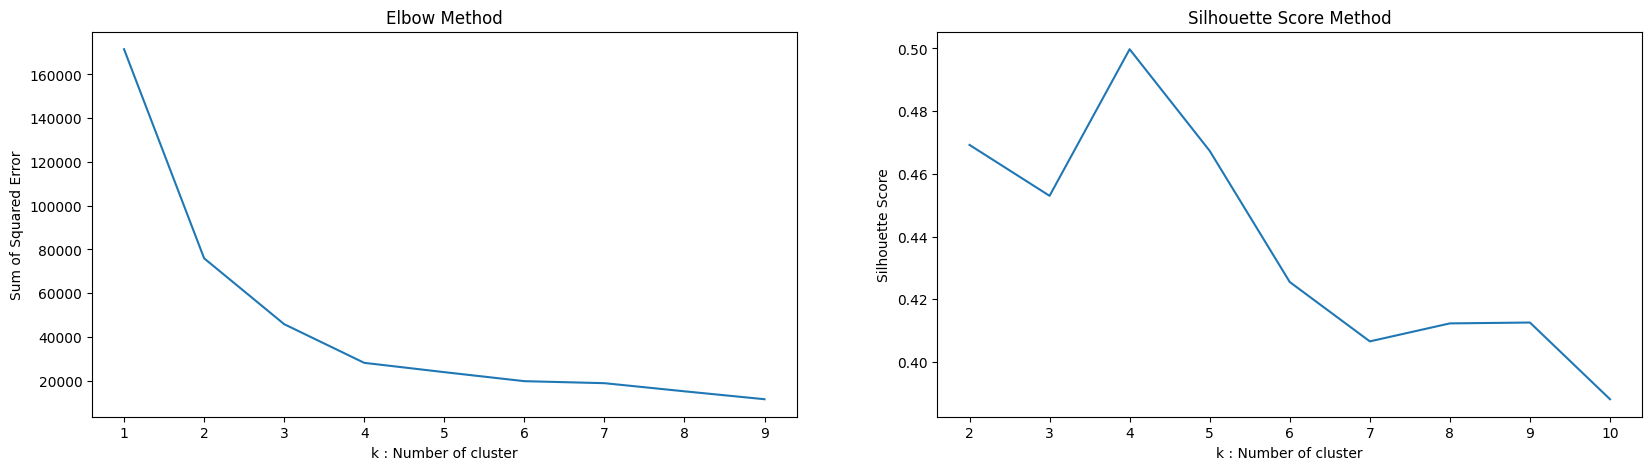

In [44]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 4**

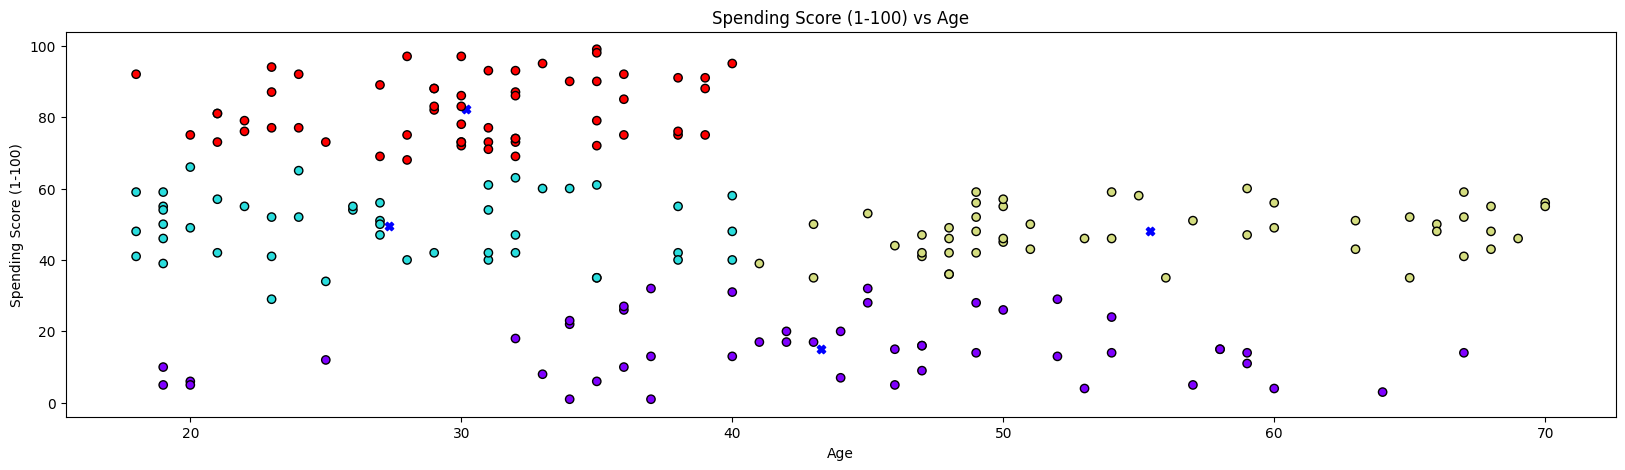

In [45]:
model = KMeans(n_clusters = 4,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df1['Age'], df1['Spending Score (1-100)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

### Conjunto de datos normalizado :

#### Método del codo y método de la puntuación de silueta :

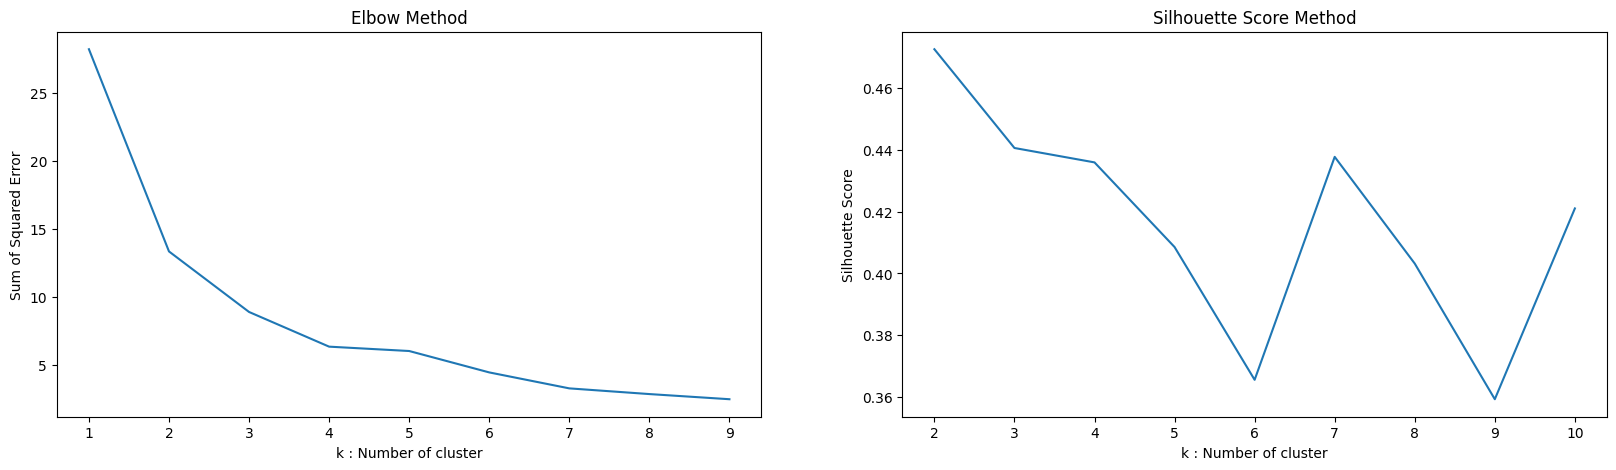

In [46]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 6**

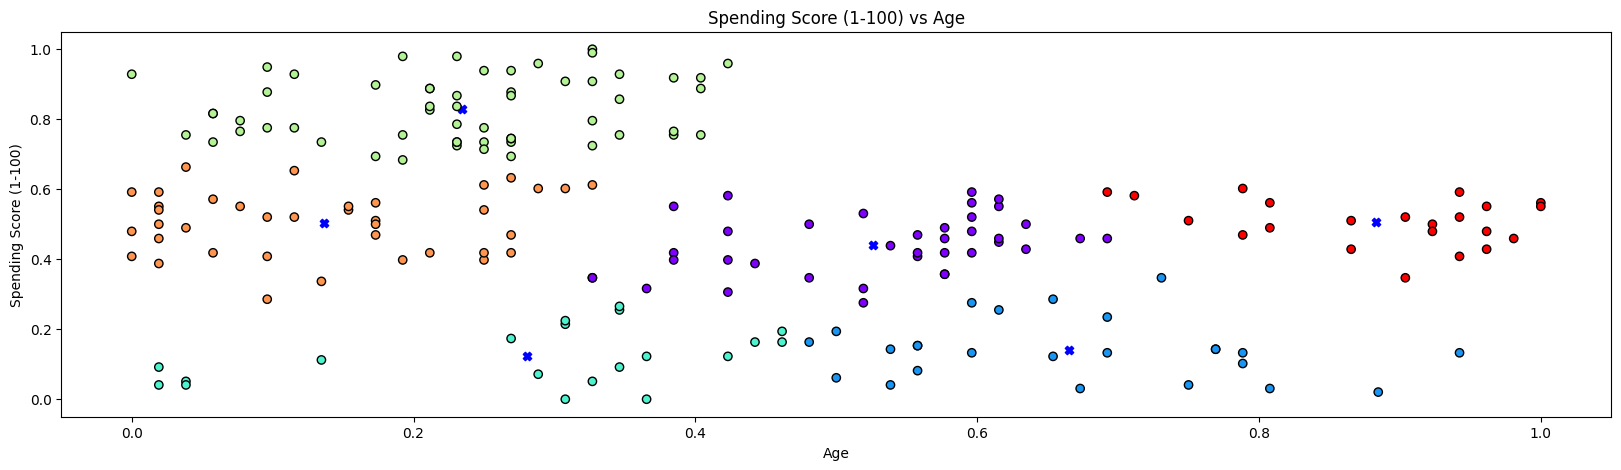

In [47]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df2['Age'], df2['Spending Score (1-100)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

### <center>Ingreso Anual (k\$) - Puntaje de Gasto (1-100)</center>

In [48]:
m1 = df1[['Annual Income (k$)', 'Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Annual Income (k$)', 'Spending Score (1-100)']].values # Normalized Dataset

### Conjunto de datos original :

#### Método del codo y método de la puntuación de silueta :

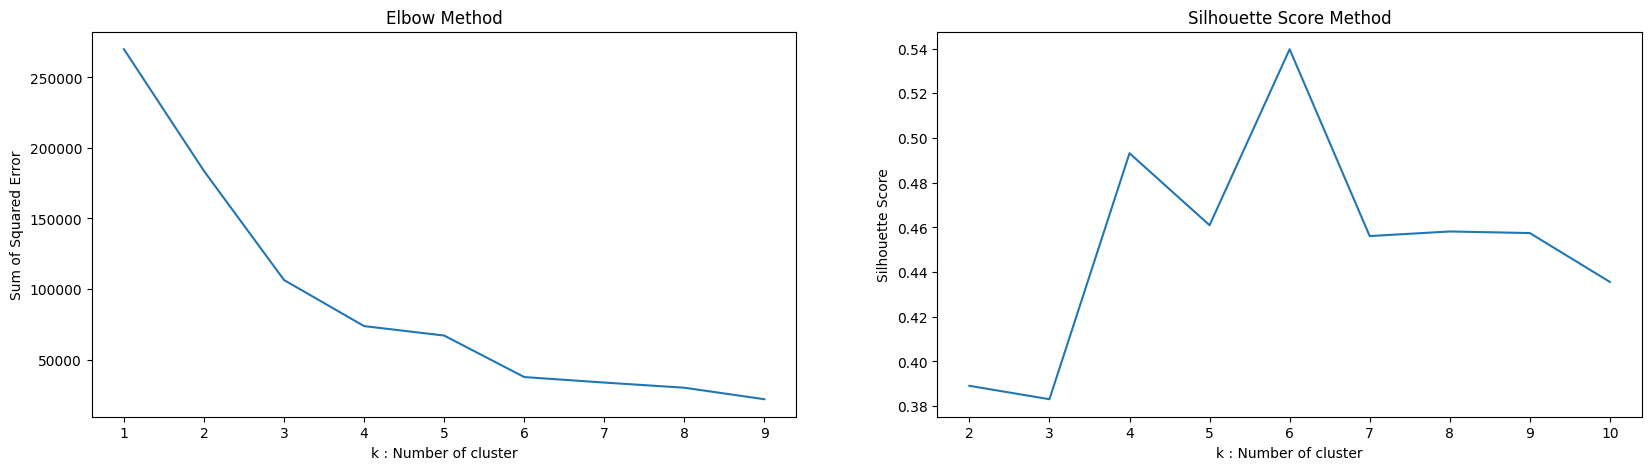

In [49]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 5**

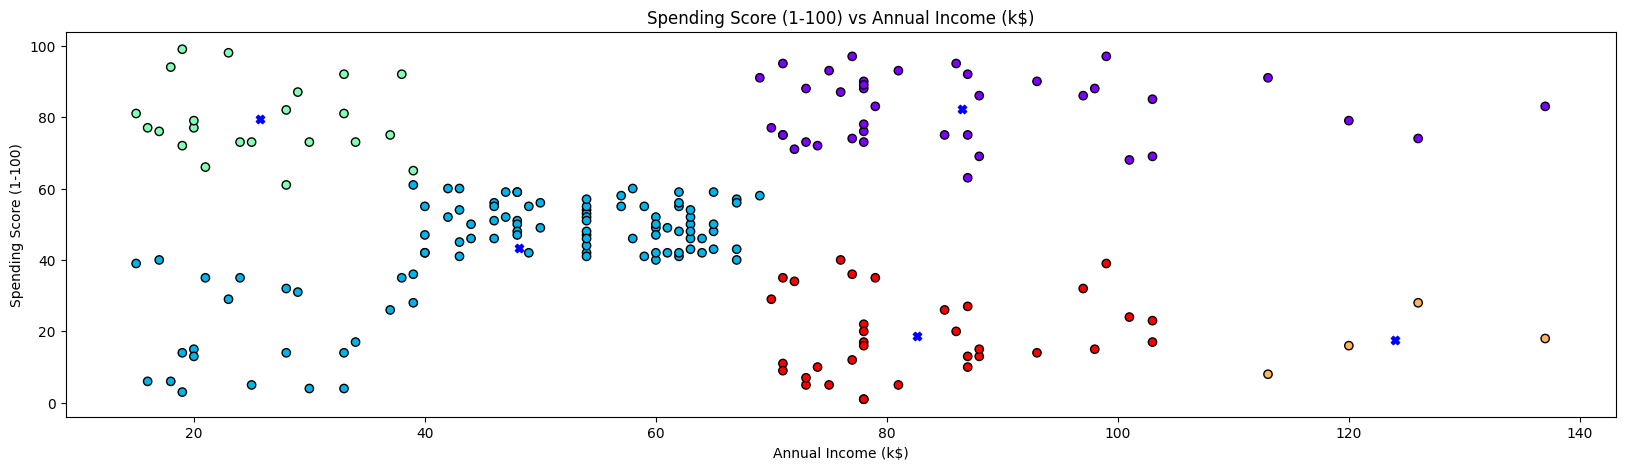

In [50]:
model = KMeans(n_clusters = 5,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df1['Annual Income (k$)'], df1['Spending Score (1-100)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

### Conjunto de datos normalizado :

#### Método del codo y método de la puntuación de silueta :

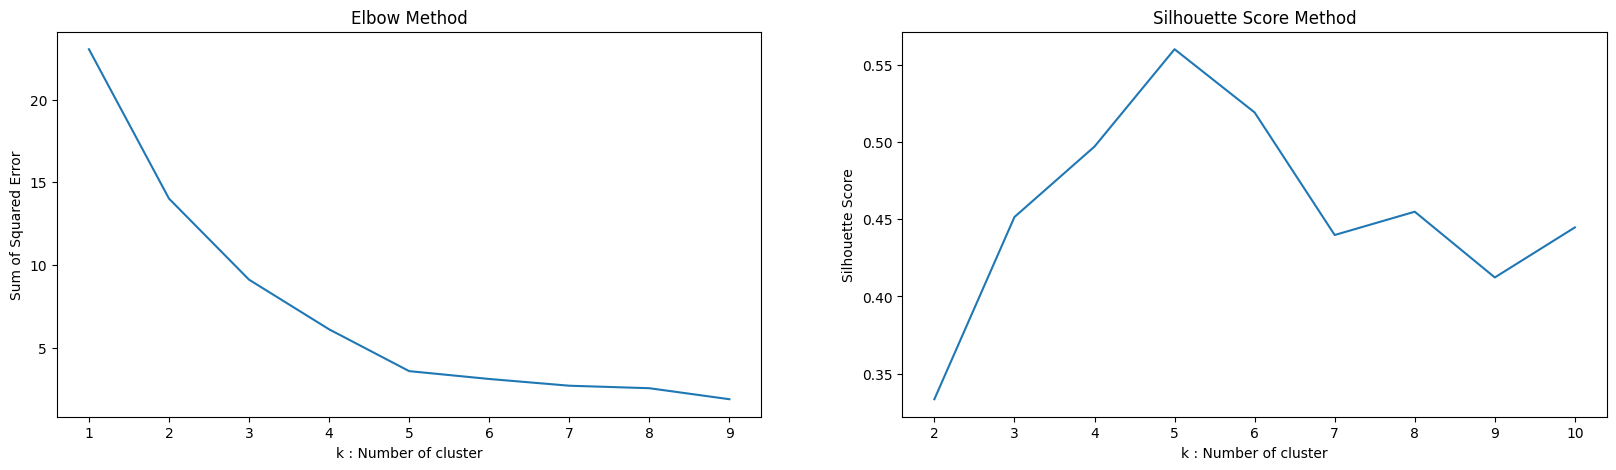

In [51]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 5**

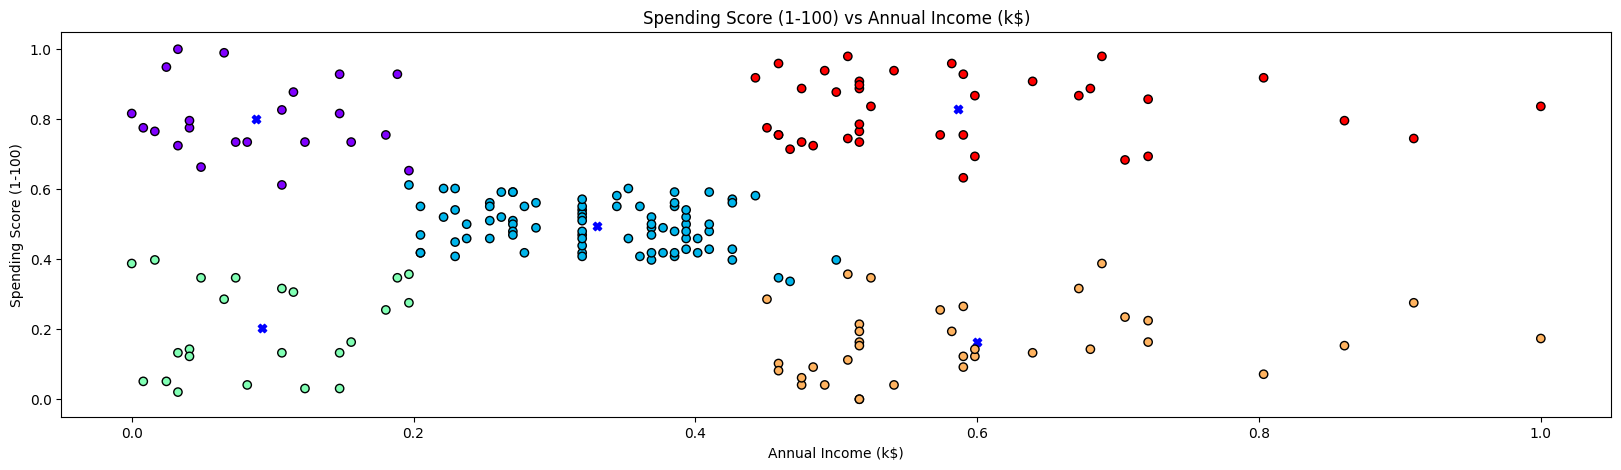

In [52]:
model = KMeans(n_clusters = 5,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(df2['Annual Income (k$)'], df2['Spending Score (1-100)'], c = labels, cmap = 'rainbow', edgecolor = 'black')
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

### <center>Edad - Ingreso Anual (k\$) - Puntaje de Gasto (1-100)</center>

In [53]:
m1 = df1[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Normalized Dataset

### Conjunto de datos original :

#### Método del codo y método de la puntuación de silueta :

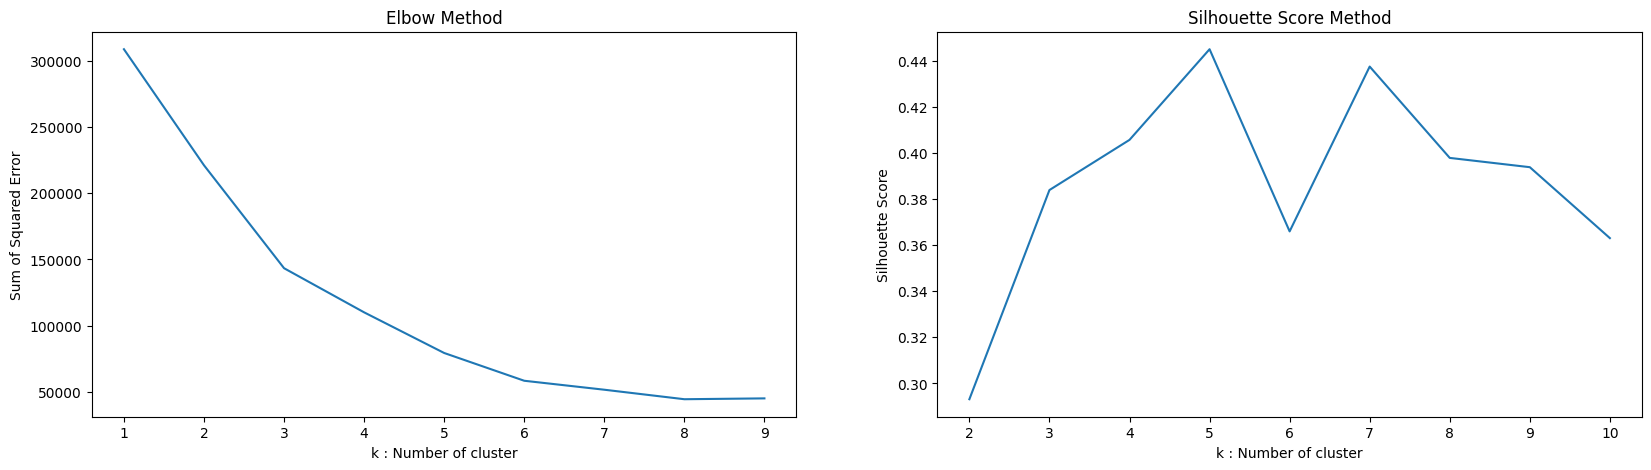

In [54]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 6**

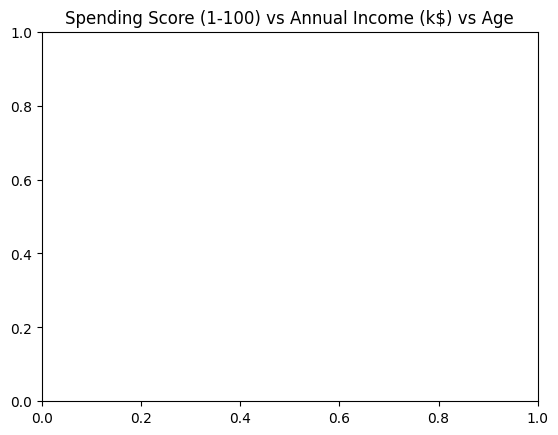

In [55]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure()
ax = Axes3D(fig)
x = np.array(df1['Annual Income (k$)'])
y = np.array(df1['Spending Score (1-100)'])
z = np.array(df1['Age'])
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2],marker="X", color = 'b')
ax.scatter(x,y,z,c = y)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.show();

### Conjunto de datos normalizado

#### Método del codo y método de la puntuación de silueta :

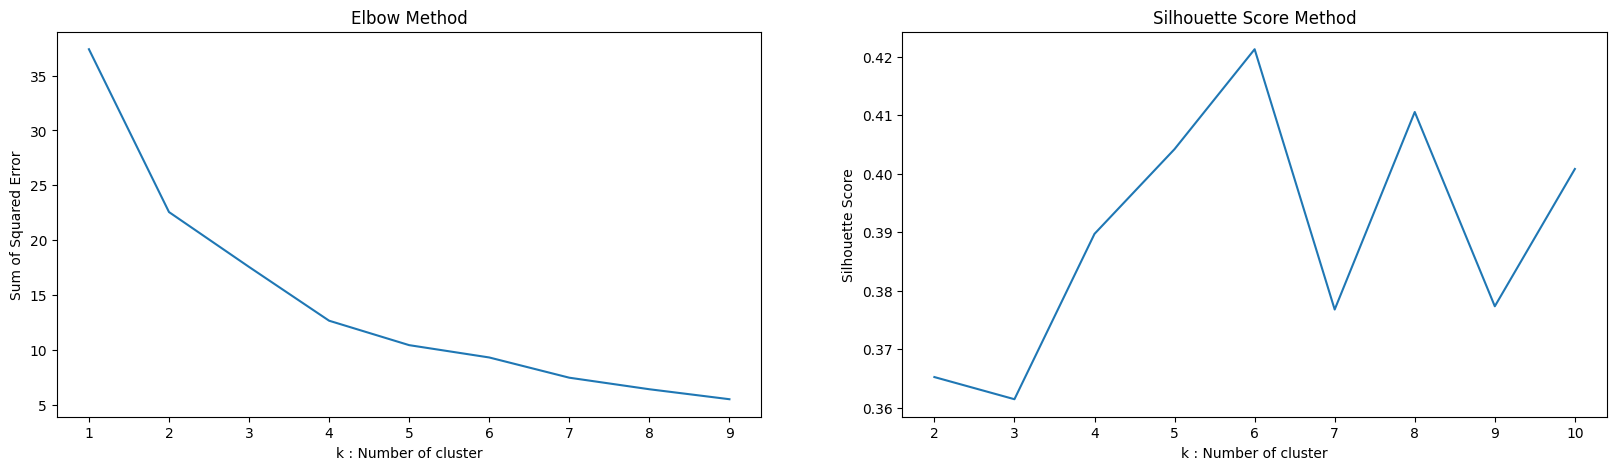

In [56]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

- De los resultados de los 2 métodos anteriores, seleccionamos :
    - **k : Clústeres = 6**

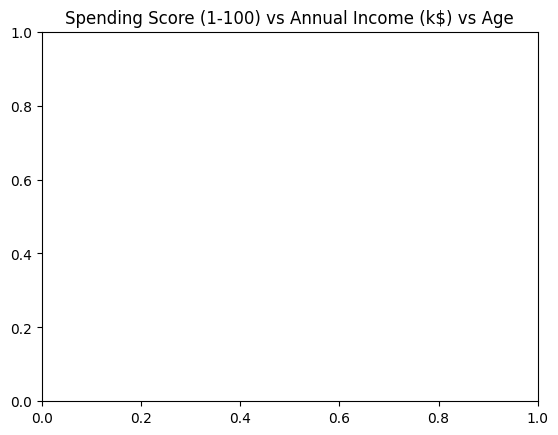

In [57]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure()
ax = Axes3D(fig)
x = np.array(df2['Annual Income (k$)'])
y = np.array(df2['Spending Score (1-100)'])
z = np.array(df2['Age'])
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2],marker = "X", color = 'b')
ax.scatter(x,y,z,c = y)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.show();

### <center>Tabla de Resultados</center>

#### Conjunto de datos original :

|Sr. No.|Combinación de Características|Número de Clústeres|
|-|-|-|
|1.|Edad - Ingreso Anual (k\$)|4|
|2.|Edad - Puntaje de Gasto (1-100)|4|
|3.|Ingreso Anual (k\$) - Puntaje de Gasto (1-100)|5|
|4.|Edad - Ingreso Anual (k\$) - Puntaje de Gasto (1-100)|6|

#### Conjunto de datos normalizado :

|Sr. No.|Combinación de Características|Número de Clústeres|
|-|-|-|
|1.|Edad - Ingreso Anual (k\$)|3|
|2.|Edad - Puntaje de Gasto (1-100)|6|
|3.|Ingreso Anual (k\$) - Puntaje de Gasto (1-100)|5|
|4.|Edad - Ingreso Anual (k\$) - Puntaje de Gasto (1-100)|6|

# <center>Conclusión</center>

- Este conjunto de datos es excelente para entender cómo abordar problemas de aprendizaje no supervisado. Presenta la oportunidad de trabajar en un problema de negocio y crear estrategias para aumentar las ventas.
- Para problemas de aprendizaje no supervisado, el EDA es muy valioso para descubrir conocimientos ocultos. Sin embargo, la complejidad de las visualizaciones puede ser un obstáculo cuando aumentan las características y el tamaño de los datos.
- Para el algoritmo de agrupamiento K-Means, la selección del hiperparámetro **k** es crucial y se hace con ayuda de pruebas estadísticas. En este caso, no hay mucha diferencia en el rendimiento del modelo cuando se entrena con el conjunto de datos original o normalizado.